<a href="https://colab.research.google.com/github/davidogm/DataScience/blob/main/ITBD/notebooks/spark/ITBD_W2_Del_DataFrame_al_Procesamiento_Distribuido.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# ITBD — Del DataFrame al procesamiento distribuido con PySpark
**Semana 3 · Notebook guiado**

Este notebook retoma la idea central de que **la escala cambia la arquitectura**. Resolveremos la misma pregunta primero con **pandas** y después con **PySpark**.

### Objetivos
- Entender por qué el número de filas no determina por sí solo si un problema es Big Data.
- Diferenciar tamaño en disco y memoria de procesamiento.
- Comprender **particiones**, **Transformations**, **Actions**, **Lazy Evaluation** y **Shuffle**.
- Comparar el modelo local de pandas con el modelo de ejecución de Spark.

> **Pregunta guía:** ¿Qué cambia cuando los datos dejan de poder procesarse cómodamente en una sola máquina?

## 0. Preparación del entorno
Google Colab será nuestra máquina de trabajo. Instalaremos PySpark y crearemos una `SparkSession`, el punto de entrada para trabajar con Spark desde Python.

**Importante:** normalmente estaremos en `local[*]`: no tenemos un clúster de varias máquinas, pero podemos estudiar el mismo modelo de DataFrames, particiones, transformations y actions que después se utiliza en un clúster.

In [1]:
!pip -q install pyspark

In [2]:
import os, time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pyspark.sql import SparkSession
from pyspark.sql import functions as F

spark = SparkSession.builder.appName("ITBD-W2").getOrCreate()
print("Versión de Spark:", spark.version)
print("Master:", spark.sparkContext.master)

Versión de Spark: 4.0.4
Master: local[*]


### ¿Qué significa `local[*]`?
- `local`: Spark se ejecuta en esta máquina.
- `*`: puede utilizar los núcleos disponibles.

En un clúster real, el **Driver** coordina y los **Executors** realizan tareas sobre particiones distribuidas entre máquinas.

# 1. Nuestro dataset de movilidad
Simularemos viajes urbanos con **fecha/hora · zona · distancia · duración · tarifa · pasajeros**.

Generaremos **2 millones de viajes**.

### Antes de ejecutar
**¿Consideraríais 2 millones de registros Big Data?**

Guarda tu respuesta. Volveremos a ella al final.

> El código de generación sólo crea un dataset reproducible; no es el objetivo de la práctica.

In [3]:
N = 2_000_000
SEED = 42
rng = np.random.default_rng(SEED)

start = np.datetime64("2026-09-01T00:00")
minutes = rng.integers(0, 30*24*60, size=N)
pickup_datetime = start + minutes.astype("timedelta64[m]")

zones = np.array(["Centro","Norte","Sur","Este","Oeste","Universidad"])
zone = rng.choice(zones, size=N, p=[0.28,0.14,0.16,0.14,0.13,0.15])

trip_distance = np.round(rng.gamma(2.0, 2.2, size=N), 2)
duration_min = np.maximum(2, np.round(trip_distance*rng.normal(4.0,0.8,size=N),1))
fare_amount = np.round(2.5 + trip_distance*rng.normal(1.7,0.15,size=N),2)
passengers = rng.integers(1,5,size=N)

pdf = pd.DataFrame({
    "pickup_datetime": pickup_datetime, "zone": zone,
    "trip_distance": trip_distance, "duration_min": duration_min,
    "fare_amount": fare_amount, "passengers": passengers
})
pdf.head()

,pickup_datetime,zone,trip_distance,duration_min,fare_amount,passengers
0,2026-09-03 16:15:00,Este,2.38,8.7,6.76,2
1,2026-09-24 05:14:00,Centro,2.85,11.1,7.24,3
2,2026-09-20 15:17:00,Oeste,7.11,34.7,15.26,3
3,2026-09-14 03:59:00,Universidad,2.11,10.5,6.75,3
4,2026-09-13 23:46:00,Universidad,1.11,5.2,4.40,4


## ¿Dónde están ahora los registros?
`pdf` es un **pandas DataFrame** residente en la memoria de nuestra máquina.

```text
datos → RAM → pandas DataFrame
```

Pandas funciona muy bien mientras los datos y las operaciones sean manejables con los recursos de una sola máquina.

## 1.1 ¿Cuánto ocupa realmente?
El número de filas no nos dice por sí solo cuánto cuesta almacenar o procesar el dataset.

In [4]:
memory_mb = pdf.memory_usage(deep=True).sum()/1024**2
print(f"Filas: {len(pdf):,}")
print(f"Columnas: {len(pdf.columns)}")
print(f"Memoria del DataFrame: {memory_mb:.2f} MB")

Filas: 2,000,000
Columnas: 6
Memoria del DataFrame: 180.66 MB


## 1.2 Guardamos en CSV
Persistimos los mismos datos y comparamos el tamaño en disco con su representación en memoria.

In [5]:
path="/content/vigia_mobility.csv"
pdf.to_csv(path,index=False)
file_mb=os.path.getsize(path)/1024**2
print(f"Tamaño CSV: {file_mb:.2f} MB")
print(f"Memoria DataFrame: {memory_mb:.2f} MB")

Tamaño CSV: 83.26 MB
Memoria DataFrame: 180.66 MB


### Pregunta
**¿Por qué el CSV y el DataFrame no ocupan lo mismo?**

Al cargar el fichero, pandas construye columnas, tipos, índices y estructuras internas.

> **Tamaño en disco ≠ memoria necesaria para procesarlo.**

Además, las operaciones pueden crear copias y resultados intermedios.

In [6]:
for factor in [1,10,100,1000]:
    print(f"{len(pdf)*factor:>15,} filas → ~{memory_mb*factor:,.0f} MB (estimación lineal)")

      2,000,000 filas → ~181 MB (estimación lineal)
     20,000,000 filas → ~1,807 MB (estimación lineal)
    200,000,000 filas → ~18,066 MB (estimación lineal)
  2,000,000,000 filas → ~180,663 MB (estimación lineal)


### Reflexión
**¿Cuándo dejaría de ser razonable cargar todo con pandas?**

No existe una cifra universal. Depende de **datos + representación + RAM + operaciones + tiempo + arquitectura**.

Por eso no existe un número mágico de filas que defina Big Data.

# 2. Los datos también pueden tener problemas
Introduciremos valores imposibles y ausentes para simular una pequeña fase de calidad de datos.

In [7]:
bad_idx=rng.choice(N,size=4000,replace=False)
pdf.loc[bad_idx[:1500],"trip_distance"]=-1
pdf.loc[bad_idx[1500:3000],"fare_amount"]=-5
pdf.loc[bad_idx[3000:],"zone"]=pd.NA
pdf.to_csv(path,index=False)

## 2.1 Exploración con pandas
Antes de procesar debemos conocer **estructura, tipos, valores ausentes y anomalías**.

In [8]:
pdf.head()

,pickup_datetime,zone,trip_distance,duration_min,fare_amount,passengers
0,2026-09-03 16:15:00,Este,2.38,8.7,6.76,2
1,2026-09-24 05:14:00,Centro,2.85,11.1,7.24,3
2,2026-09-20 15:17:00,Oeste,7.11,34.7,15.26,3
3,2026-09-14 03:59:00,Universidad,2.11,10.5,6.75,3
4,2026-09-13 23:46:00,Universidad,1.11,5.2,4.40,4


In [9]:
pdf.info(memory_usage="deep")

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000000 entries, 0 to 1999999
Data columns (total 6 columns):
 #   Column           Dtype        
---  ------           -----        
 0   pickup_datetime  datetime64[s]
 1   zone             object       
 2   trip_distance    float64      
 3   duration_min     float64      
 4   fare_amount      float64      
 5   passengers       int64        
dtypes: datetime64[s](1), float64(3), int64(1), object(1)
memory usage: 180.7 MB


In [10]:
pdf.isna().sum()

,0
pickup_datetime,0
zone,1000
trip_distance,0
duration_min,0
fare_amount,0
passengers,0


In [11]:
quality=pd.Series({
    "Filas totales":len(pdf),
    "Distancias <= 0":(pdf["trip_distance"]<=0).sum(),
    "Tarifas <= 0":(pdf["fare_amount"]<=0).sum(),
    "Zonas ausentes":pdf["zone"].isna().sum()
})
quality

,0
Filas totales,2000000
Distancias <= 0,1503
Tarifas <= 0,1500
Zonas ausentes,1000


> **2 millones de registros no significan 2 millones de registros válidos.**

Creamos una nueva versión preparada sin modificar el DataFrame original.

In [12]:
pandas_clean=pdf[
    (pdf["trip_distance"]>0) &
    (pdf["fare_amount"]>0) &
    (pdf["zone"].notna())
].copy()
print(f"Antes: {len(pdf):,}")
print(f"Después: {len(pandas_clean):,}")

Antes: 2,000,000
Después: 1,995,997


# 3. Del dato a la información
### Pregunta analítica: ¿cómo varía la movilidad a lo largo del día?

El objetivo no es tener datos, sino convertirlos en información útil.

In [13]:
pandas_clean["hour"]=pandas_clean["pickup_datetime"].dt.hour
t0=time.perf_counter()
pandas_by_hour=(pandas_clean.groupby("hour").size().rename("trips").reset_index())
pandas_time=time.perf_counter()-t0
print(f"Tiempo pandas: {pandas_time:.3f} s")
pandas_by_hour

Tiempo pandas: 0.041 s


,hour,trips
0,0,83235
1,1,83563
2,2,82668
3,3,83282
4,4,82917
5,5,83178
6,6,83082
7,7,83268
8,8,82773
9,9,83439


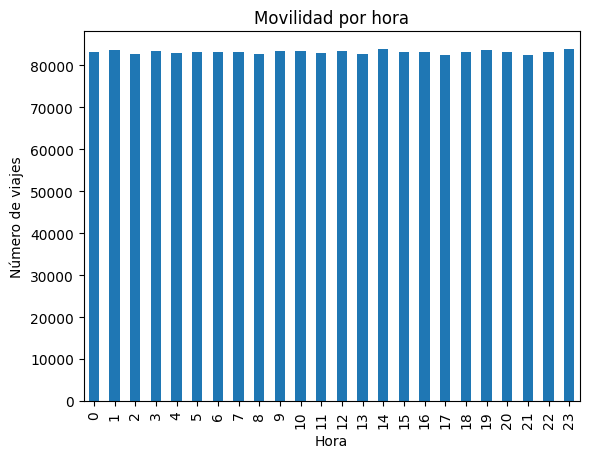

In [14]:
pandas_by_hour.plot(x="hour",y="trips",kind="bar",legend=False,title="Movilidad por hora")
plt.xlabel("Hora"); plt.ylabel("Número de viajes"); plt.show()

Hemos pasado de millones de registros a 24 valores:

**datos → limpieza → transformación → agrupación → información → interpretación**

## Entonces... ¿para qué necesitamos Spark?
Pandas ha resuelto perfectamente este problema.

> El problema no es que pandas deje de saber hacer un `groupby`; cambia **cómo debe ejecutarse** cuando datos o procesamiento superan los recursos cómodos de una máquina.

# 4. El mismo dataset con Spark
Resolveremos la misma pregunta con PySpark.

In [15]:
sdf=(spark.read.option("header",True).option("inferSchema",True).csv(path))
print(type(sdf))
sdf.printSchema()
sdf.show(5)

<class 'pyspark.sql.classic.dataframe.DataFrame'>
root
 |-- pickup_datetime: timestamp (nullable = true)
 |-- zone: string (nullable = true)
 |-- trip_distance: double (nullable = true)
 |-- duration_min: double (nullable = true)
 |-- fare_amount: double (nullable = true)
 |-- passengers: integer (nullable = true)

+-------------------+-----------+-------------+------------+-----------+----------+
|    pickup_datetime|       zone|trip_distance|duration_min|fare_amount|passengers|
+-------------------+-----------+-------------+------------+-----------+----------+
|2026-09-03 16:15:00|       Este|         2.38|         8.7|       6.76|         2|
|2026-09-24 05:14:00|     Centro|         2.85|        11.1|       7.24|         3|
|2026-09-20 15:17:00|      Oeste|         7.11|        34.7|      15.26|         3|
|2026-09-14 03:59:00|Universidad|         2.11|        10.5|       6.75|         3|
|2026-09-13 23:46:00|Universidad|         1.11|         5.2|        4.4|         4|
+----------

# 5. Particiones
Spark organiza los datos en **particiones**, unidades de trabajo procesables de forma independiente.

```text
DATASET
  ├─ P0 → tarea
  ├─ P1 → tarea
  └─ P2 → tarea
```

Antes dividíamos en *chunks* para controlar memoria. Ahora las particiones permiten además organizar trabajo potencialmente paralelo.

In [16]:
print("Número de particiones:",sdf.rdd.getNumPartitions())

Número de particiones: 2


In [17]:
sdf_with_partition=sdf.withColumn("partition_id",F.spark_partition_id())
(sdf_with_partition.groupBy("partition_id").count().orderBy("partition_id").show())

+------------+-------+
|partition_id|  count|
+------------+-------+
|           0|1048020|
|           1| 951980|
+------------+-------+



> **Spark paraleliza tareas sobre particiones, no filas individuales.**

En `local[*]` se usan recursos de una máquina; en un clúster, Executors de distintas máquinas pueden procesar particiones.

**Más particiones no significa siempre más velocidad:** pocas pueden limitar paralelismo y demasiadas añaden coordinación.

# 6. Transformations
Una **Transformation** toma uno o más DataFrames y define un nuevo DataFrame.

Ejemplos: `filter()` · `select()` · `withColumn()` · `groupBy()` · `join()` · `orderBy()`.

No significa necesariamente “cambiar valores”: filtrar, seleccionar o relacionar datos también son transformaciones.

In [18]:
spark_clean=(
    sdf
    .filter(F.col("trip_distance")>0)
    .filter(F.col("fare_amount")>0)
    .filter(F.col("zone").isNotNull())
    .withColumn("hour",F.hour("pickup_datetime"))
)

spark_by_hour=(
    spark_clean
    .groupBy("hour")
    .agg(F.count("*").alias("trips"))
    .orderBy("hour")
)

### Pregunta clave
**¿Spark ha tenido que recorrer ya los 2 millones de registros?**

No necesariamente. Hemos definido **qué queremos obtener**.

# 7. Lazy Evaluation
Spark utiliza **evaluación diferida**.

Las transformations construyen un plan y Spark espera hasta que necesitamos un resultado.

```text
filter → withColumn → groupBy → agg → orderBy
                    ↓
              PLAN DE OPERACIONES
                    ↓
                  esperar
```

Esto permite considerar conjuntamente las operaciones antes de ejecutarlas.

# 8. Transformations vs Actions

| Transformation | Action |
|---|---|
| Describe qué queremos hacer | Solicita/produce resultado |
| Produce normalmente otro DataFrame | Desencadena ejecución |
| Evaluación diferida | Spark realiza el trabajo |
| `filter()` | `count()` |
| `select()` | `show()` |
| `withColumn()` | `collect()` |
| `groupBy()` | `take()` |
| `join()` | `write...` |

> **Transformation → describe. Action → desencadena la ejecución.**

La Action no “hace el paralelismo”: Spark planifica y ejecuta las tareas.

# 9. Action: necesitamos el resultado
Usamos `collect()` porque el resultado tiene sólo 24 filas.

In [19]:
t0=time.perf_counter()
spark_result=spark_by_hour.collect()
spark_time=time.perf_counter()-t0
print(f"Tiempo Spark: {spark_time:.3f} s")
spark_result[:5]

Tiempo Spark: 7.604 s


[Row(hour=0, trips=83235),
 Row(hour=1, trips=83563),
 Row(hour=2, trips=82668),
 Row(hour=3, trips=83282),
 Row(hour=4, trips=82917)]

`collect()`:
1. desencadena la ejecución necesaria;
2. trae **todas las filas del resultado al Driver**.

Aquí es seguro: son 24 filas. Hacer `collect()` sobre un DataFrame enorme puede agotar la memoria del Driver.

In [20]:
spark_by_hour.show(24)

+----+-----+
|hour|trips|
+----+-----+
|   0|83235|
|   1|83563|
|   2|82668|
|   3|83282|
|   4|82917|
|   5|83178|
|   6|83082|
|   7|83268|
|   8|82773|
|   9|83439|
|  10|83372|
|  11|82997|
|  12|83365|
|  13|82693|
|  14|83881|
|  15|83227|
|  16|83160|
|  17|82505|
|  18|83157|
|  19|83592|
|  20|83055|
|  21|82551|
|  22|83200|
|  23|83837|
+----+-----+



# 10. Del plan a la ejecución
```text
ACTION
  ↓
Plan de Spark
  ↓
P0 → Task
P1 → Task
P2 → Task
  ↓
Resultado → Driver
```

En local, las tareas usan los recursos disponibles de una máquina. En un clúster pueden ejecutarse en Executors de varias máquinas.

# 11. Shuffle
En `groupBy("hour")`, registros de una misma hora pueden estar en distintas particiones.

```text
P0          P1          P2
8h, 9h      9h, 8h      8h, 10h
  \          |          /
       SHUFFLE
          ↓
    redistribuir por hour
      ↓     ↓     ↓
     8h    9h    10h
```

Un **Shuffle** es una redistribución de datos entre particiones para que determinados datos puedan procesarse conjuntamente.

Esto recupera la idea: **dividir → procesar → combinar**.

## ¿Por qué importa?
Mover datos tiene coste: puede implicar red, memoria, disco, serialización y coordinación.

> **Más máquinas no significa automáticamente más velocidad.**

Operaciones que pueden provocar redistribución incluyen `groupBy()`, `join()`, `orderBy()` y `distinct()`.

# 12. El plan de Spark, sin complicarlo
Nuestro modelo conceptual es:

**LEER → FILTRAR → TRANSFORMAR → AGRUPAR → AGREGAR → ORDENAR → DEVOLVER**

Podemos mirar el plan real con `explain()`, pero no necesitamos descifrar todos sus detalles.

In [21]:
spark_by_hour.explain(mode="simple")

== Physical Plan ==
AdaptiveSparkPlan isFinalPlan=true
+- == Final Plan ==
   ResultQueryStage 2
   +- *(3) Sort [hour#74 ASC NULLS FIRST], true, 0
      +- AQEShuffleRead coalesced
         +- ShuffleQueryStage 1
            +- Exchange rangepartitioning(hour#74 ASC NULLS FIRST, 200), ENSURE_REQUIREMENTS, [plan_id=165]
               +- *(2) HashAggregate(keys=[hour#74], functions=[count(1)])
                  +- AQEShuffleRead coalesced
                     +- ShuffleQueryStage 0
                        +- Exchange hashpartitioning(hour#74, 200), ENSURE_REQUIREMENTS, [plan_id=134]
                           +- *(1) HashAggregate(keys=[hour#74], functions=[partial_count(1)])
                              +- *(1) Project [hour(pickup_datetime#17, Some(Etc/UTC)) AS hour#74]
                                 +- *(1) Filter ((((isnotnull(trip_distance#19) AND isnotnull(fare_amount#21)) AND (trip_distance#19 > 0.0)) AND (fare_amount#21 > 0.0)) AND isnotnull(zone#18))
                       

Por ahora basta reconocer términos como:
- `Filter` → filtrado;
- `Aggregate` → agregación;
- `Exchange` → puede reflejar redistribución de datos.

No es necesario interpretar todavía todo el plan físico.

# 13. Modelo mental de Spark
```text
DataFrame
   ↓
TRANSFORMATIONS
   ↓
LAZY EVALUATION
   ↓
Plan de Spark
   ↓
ACTION
   ↓
Tasks sobre particiones
   ↓
posible SHUFFLE
   ↓
RESULTADO → Driver
```

> **Nosotros describimos las transformaciones. Spark planifica y ejecuta el trabajo sobre las particiones disponibles.**

# 14. pandas vs PySpark

| | pandas | PySpark |
|---|---|---|
| Abstracción | DataFrame | DataFrame |
| Filtrar | `df[...]` | `filter()` |
| Agrupar | `groupby()` | `groupBy()` |
| Agregar | `agg()` | `agg()` |
| Ejecución | Principalmente local | Preparada para distribuida |
| Evaluación | Habitualmente inmediata | Lazy para transformations |
| Datos | Recursos de una máquina | Particionados |
| Escalado | Principalmente scale-up | Permite scale-out |

### ¿Spark es siempre mejor?
**No.** Para datasets pequeños, pandas puede ser más sencillo y tener menos *overhead*. Spark introduce planificación, particiones, tareas y coordinación, cuyo coste tiene sentido cuando necesitamos escalar.

# 15. Volvemos a la pregunta inicial
## ¿2 millones de registros son Big Data?

El número de registros por sí solo no permite responder.

Debemos considerar:

**datos + problema + recursos + tiempo + arquitectura**

> **La escala cambia la arquitectura.**

# 16. Ejercicio final — Ahora vosotros
### Pregunta
**¿Qué zonas presentan mayor movilidad y cuál es su distancia media de viaje?**

Construid una solución PySpark que utilice:
1. `filter()` para registros válidos;
2. `withColumn()` para crear una variable derivada;
3. `groupBy()` por zona;
4. `agg()` para número de viajes, distancia media y tarifa media;
5. una **Action** para obtener o visualizar el resultado.

Antes de ejecutar:
- ¿Qué operaciones son Transformations?
- ¿Cuál será la Action?
- ¿Dónde esperáis un Shuffle y por qué?

**Tiempo recomendado: 15–20 minutos.**

In [22]:
# TODO: vuestra solución
resultado = (
    sdf
    # .filter(...)
    # .withColumn(...)
    # .groupBy(...)
    # .agg(...)
)

# ACTION:
# resultado.show()

### Pista opcional
Podéis crear, por ejemplo, una velocidad media aproximada:

```python
.withColumn(
    "speed_kmh",
    F.col("trip_distance") / (F.col("duration_min") / 60)
)
```

Y utilizar `F.count("*")`, `F.avg("trip_distance")` y `F.avg("fare_amount")`.

# 17. Conexión con la arquitectura Vigía
En este notebook hemos usado un CSV local para concentrarnos en el modelo de procesamiento. El siguiente paso será:

```text
Fuentes
  ↓
S3 Data Lake
  ↓
Catálogo / preparación
  ↓
Parquet + particiones
  ↓
Spark / PySpark
  ↓
agregaciones + joins
  ↓
resultados procesados
  ↓
Athena / visualización
```

Después pasaremos a un dataset real de movilidad y escalaremos progresivamente el volumen.

> **Almacenar datos no es suficiente: debemos conocerlos, prepararlos y disponer de una arquitectura capaz de procesarlos a la escala requerida.**